# 🌧️ GRU — Estación El Junco (JUN) v3
**SALA Hackathon 2026 | Precipitation Nowcasting**

| Parámetro | Valor |
|---|---|
| Estación | El Junco (548 m s.n.m.) — San Cristóbal, Galápagos |
| Resolución de entrada | **1 hora** — datos ya están en formato horario |
| Tarea | **Clasificación 3 clases**: No rain / Light / Heavy |
| Horizontes | +1 h / +3 h / +6 h (un modelo por horizonte) |
| Arquitectura | GRU con recurrent_dropout |
| Split temporal | Train ≤ 2019-03-31 · Val 2019-04 to 2020-02 · Test ≥ 2020-03-01 |


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

RAIN_COLORS = ['#4D6E91', '#F4A460', '#C0392B']
CLASS_NAMES = ['No rain', 'Light', 'Heavy']
JUN_COLOR   = '#A23B72'

print(f'TensorFlow : {tf.__version__}')
print(f'Pandas     : {pd.__version__}')

TensorFlow : 2.21.0
Pandas     : 2.3.3


## 2. Carga del Dataset Horario

> El dataset ya está en resolución de **1 hora** (1 fila = 1 hora).  
> La columna `rain_mm` contiene la precipitación acumulada en esa hora.

In [3]:
# ============================================================
# AJUSTA ESTA RUTA AL ARCHIVO CSV HORARIO DE LA ESTACIÓN JUN
# ============================================================
FILE_PATH = '../Datasets/JUN_consolid_f15.csv'   # <-- cambia aquí

df = pd.read_csv(
    FILE_PATH,
    parse_dates=['TIMESTAMP'],
    index_col='TIMESTAMP',
    na_values=['NA', 'NaN', '']
)

# Asegurar índice con frecuencia horaria regular
df = df.asfreq('1h')

print(f'Shape   : {df.shape}')
print(f'Rango   : {df.index.min()} → {df.index.max()}')
print(f'Columnas: {df.columns.tolist()}')
df.head(5)

Shape   : (93832, 53)
Rango   : 2015-06-22 15:00:00 → 2026-03-06 06:00:00
Columnas: ['BattV_Avg', 'PTemp_C_Avg', 'LWmV_Avg', 'Rain_mm_Tot', 'AirTC_Avg', 'RH_Max', 'SlrkW_Avg', 'SlrMJ_Tot', 'NR_Wm2_Avg', 'VW', 'PA_uS', 'VW_2', 'PA_uS_2', 'VW_3', 'PA_uS_3', 'WS_ms_Avg', 'WindDir', 'BattV_Min', 'PTemp_C_Max', 'AirTC_Max', 'AirTC_Min', 'RH_Min', 'RH_Avg', 'SlrW_Max', 'SlrW_Min', 'LWmV_Max', 'LWmV_Min', 'LWMDry_Tot', 'LWMCon_Tot', 'LWMWet_Tot', 'WS_ms_Max', 'WS_ms_Min', 'WindDir_Max', 'WindDir_Min', 'VW_Max', 'VW_Min', 'PA_uS_Max', 'PA_uS_Min', 'VW_2_Max', 'VW_2_Min', 'PA_uS_2_Max', 'PA_uS_2_Min', 'VW_3_Max', 'VW_3_Min', 'PA_uS_3_Max', 'PA_uS_3_Min', 'NR_Wm2_Max', 'NR_Wm2_Min', 'CNR_Wm2_Max', 'CNR_Wm2_Min', 'CNR_Wm2_Avg', 'RECORD', 'WindDir_Avg']


,BattV_Avg,PTemp_C_Avg,LWmV_Avg,Rain_mm_Tot,AirTC_Avg,RH_Max,SlrkW_Avg,SlrMJ_Tot,NR_Wm2_Avg,VW,...,VW_3_Min,PA_uS_3_Max,PA_uS_3_Min,NR_Wm2_Max,NR_Wm2_Min,CNR_Wm2_Max,CNR_Wm2_Min,CNR_Wm2_Avg,RECORD,WindDir_Avg
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2015-06-22 15:00:00,13.340000,21.530000,280.200000,0.0,20.970000,99.9,0.217000,0.048850,191.300000,0.549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:00:00,13.116667,21.253333,338.266667,0.0,20.876667,100.0,0.040333,0.036253,28.443333,0.547,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 17:00:00,12.940000,21.020000,418.633333,0.0,20.896667,100.0,0.014667,0.013015,8.387333,0.546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 18:00:00,12.856667,20.850000,453.000000,0.0,20.543333,100.0,0.001333,0.001174,-0.892333,0.545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 19:00:00,12.826667,20.656667,469.866667,0.0,20.420000,100.0,0.000000,0.000020,-1.450000,0.544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# MAPEO DE NOMBRES DE COLUMNAS
# Si tu CSV ya tiene nombres normalizados (rain_mm, etc.)
# deja el diccionario vacío: COL_MAP = {}
# ============================================================
COL_MAP = {
    'Rain_mm_Tot' : 'rain_mm',
    'AirTC_Avg'   : 'temp_c',
    'RH_Avg'      : 'rh_avg',
    'RH_Max'      : 'rh_max',
    'SlrkW_Avg'   : 'solar_kw',
    'SlrMJ_Tot'   : 'solar_mj',
    'NR_Wm2_Avg'  : 'net_rad_wm2',
    'WS_ms_Avg'   : 'wind_speed_ms',
    'WindDir'     : 'wind_dir',
    'VW'          : 'soil_moisture_1',
    'VW_2'        : 'soil_moisture_2',
    'VW_3'        : 'soil_moisture_3',
    'LWmV_Avg'    : 'leaf_wetness',
}
df = df.rename(columns={k: v for k, v in COL_MAP.items() if k in df.columns})

assert 'rain_mm' in df.columns, '❌ Columna rain_mm no encontrada. Revisa COL_MAP.'
RAIN_COL = 'rain_mm'

# % NaN por columna
nan_pct = (df.isnull().sum() / len(df) * 100).round(1).sort_values()
print('% NaN por columna:')
print(nan_pct.to_string())

print(f'\n✅ rain_mm ok')
print(f'Horas con lluvia > 0 : {(df[RAIN_COL] > 0).sum():,} / {len(df):,}')
print(f'Total lluvia         : {df[RAIN_COL].sum():.2f} mm')
print(f'Máximo horario       : {df[RAIN_COL].max():.2f} mm')

% NaN por columna:
rain_mm              2.7
soil_moisture_3      2.7
PA_uS_3              2.7
soil_moisture_2      2.7
PA_uS_2              2.7
soil_moisture_1      2.8
PA_uS                2.8
solar_mj             3.4
solar_kw             3.4
wind_speed_ms        3.6
net_rad_wm2          9.9
BattV_Avg           12.3
PTemp_C_Avg         12.3
wind_dir            16.8
leaf_wetness        53.6
rh_max              55.4
temp_c              60.1
LWMWet_Tot          90.4
LWMCon_Tot          90.4
LWMDry_Tot          90.4
AirTC_Min           90.5
BattV_Min           90.5
PTemp_C_Max         90.5
AirTC_Max           90.5
SlrW_Max            90.5
rh_avg              90.5
RH_Min              90.5
SlrW_Min            90.5
WS_ms_Max           90.5
WS_ms_Min           90.5
VW_Max              90.5
VW_Min              90.5
CNR_Wm2_Avg         90.5
PA_uS_3_Min         90.5
PA_uS_Min           90.5
PA_uS_Max           90.5
VW_2_Max            90.5
VW_2_Min            90.5
PA_uS_2_Min         90.5
PA_uS_

## 3. Exploración Rápida

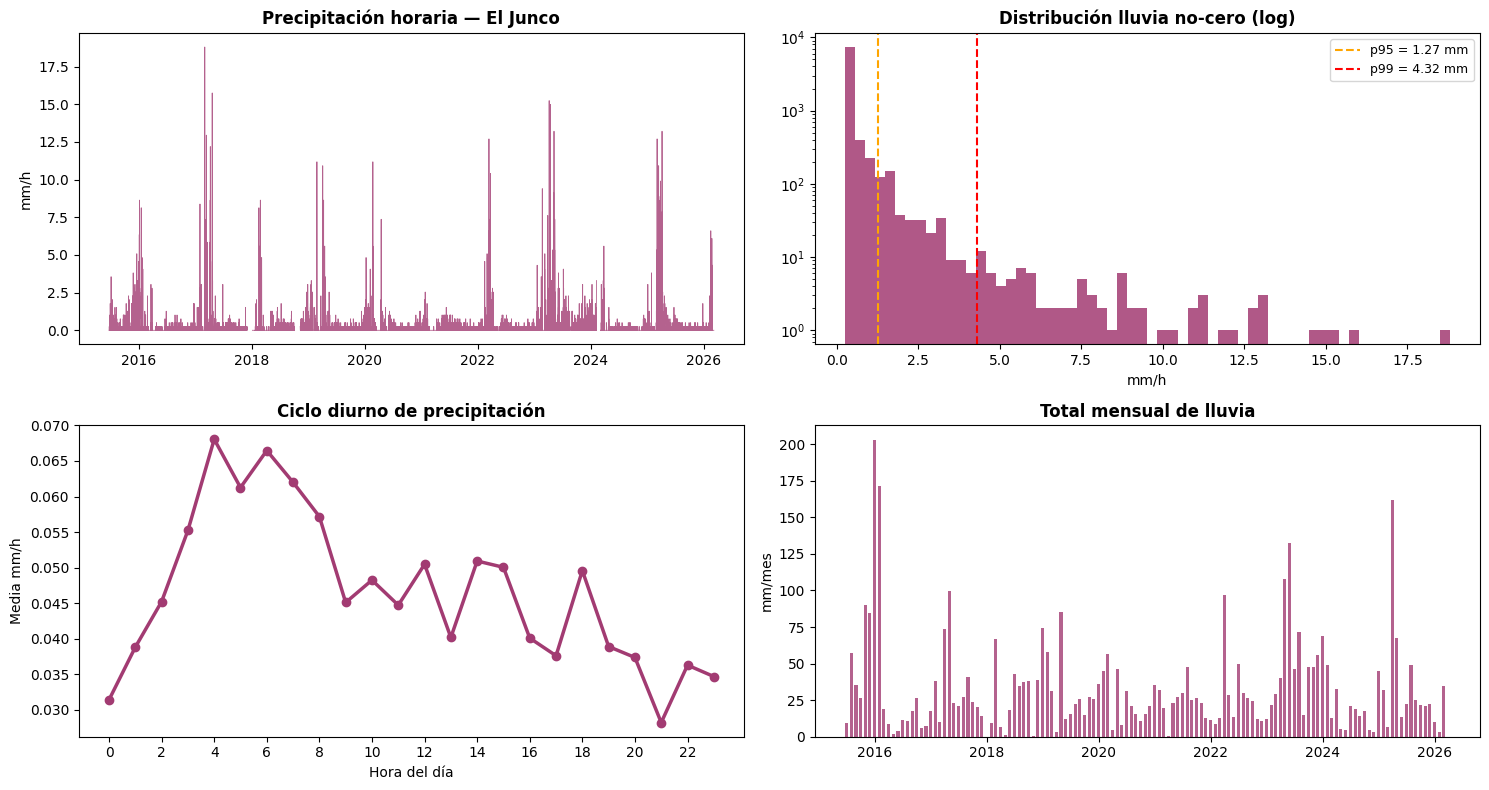

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Serie de lluvia
axes[0,0].plot(df.index, df[RAIN_COL], color=JUN_COLOR, lw=0.6, alpha=0.8)
axes[0,0].set_title('Precipitación horaria — El Junco', fontweight='bold')
axes[0,0].set_ylabel('mm/h')

# Distribución de valores no-cero (log)
nonzero = df[RAIN_COL][df[RAIN_COL] > 0]
axes[0,1].hist(nonzero, bins=60, color=JUN_COLOR, alpha=0.85, log=True)
axes[0,1].axvline(nonzero.quantile(0.95), color='orange', ls='--', lw=1.5,
                  label=f'p95 = {nonzero.quantile(0.95):.2f} mm')
axes[0,1].axvline(nonzero.quantile(0.99), color='red',    ls='--', lw=1.5,
                  label=f'p99 = {nonzero.quantile(0.99):.2f} mm')
axes[0,1].set_title('Distribución lluvia no-cero (log)', fontweight='bold')
axes[0,1].set_xlabel('mm/h'); axes[0,1].legend(fontsize=9)

# Ciclo diurno
hourly_mean = df[RAIN_COL].groupby(df.index.hour).mean()
axes[1,0].plot(hourly_mean.index, hourly_mean.values, 'o-',
               color=JUN_COLOR, lw=2.5, ms=6)
axes[1,0].set_title('Ciclo diurno de precipitación', fontweight='bold')
axes[1,0].set_xlabel('Hora del día'); axes[1,0].set_ylabel('Media mm/h')
axes[1,0].set_xticks(range(0, 24, 2))

# Totales mensuales
monthly = df[RAIN_COL].resample('ME').sum()
axes[1,1].bar(monthly.index, monthly.values, width=20,
              color=JUN_COLOR, alpha=0.8)
axes[1,1].set_title('Total mensual de lluvia', fontweight='bold')
axes[1,1].set_ylabel('mm/mes')
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('jun_exploracion.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Variables **estadísticamente significativas** (EDA del hackathon, p < 0.001, lag 1–6h antes de lluvia pesada en JUN):

| Variable | Diferencia Heavy vs No-rain |
|---|---|
| `temp_c` | +3.4 °C |
| `rh_max` | +9.97 % |
| `soil_moisture_1` | +0.067 VWC |
| `net_rad_wm2` | −47 W/m² |
| `wind_speed_ms` | −0.23 m/s |

In [6]:
# Candidatos ordenados por relevancia meteorológica
CANDIDATE_FEATURES = [
    'solar_kw',        # radiación solar
    'solar_mj',        # energía solar acumulada
    'wind_speed_ms',   # ★ precursor significativo
    'net_rad_wm2',     # ★ cae ~47 W/m² antes de lluvia pesada
    'soil_moisture_1', # ★ sube +0.07 VWC antes de lluvia pesada
    'soil_moisture_2',
    'soil_moisture_3',
    'wind_dir',
    'temp_c',          # ★ +3.4 °C antes de lluvia pesada
    'rh_max',          # ★ +9.97 % antes de lluvia pesada
    'rh_avg',
    'leaf_wetness',
]

BASE_FEATURES = []
for col in CANDIDATE_FEATURES:
    if col not in df.columns:
        print(f'  –  {col:20s}  no existe en el CSV')
        continue
    nan_p = df[col].isnull().mean() * 100
    if nan_p < 70:
        BASE_FEATURES.append(col)
        print(f'  ✅ {col:20s}  {nan_p:.1f}% NaN')
    else:
        print(f'  ✗  {col:20s}  {nan_p:.1f}% NaN — omitida')

print(f'\nFeatures base seleccionadas: {len(BASE_FEATURES)}')

  ✅ solar_kw              3.4% NaN
  ✅ solar_mj              3.4% NaN
  ✅ wind_speed_ms         3.6% NaN
  ✅ net_rad_wm2           9.9% NaN
  ✅ soil_moisture_1       2.8% NaN
  ✅ soil_moisture_2       2.7% NaN
  ✅ soil_moisture_3       2.7% NaN
  ✅ wind_dir              16.8% NaN
  ✅ temp_c                60.1% NaN
  ✅ rh_max                55.4% NaN
  ✗  rh_avg                90.5% NaN — omitida
  ✅ leaf_wetness          53.6% NaN

Features base seleccionadas: 11


In [7]:
data = df[BASE_FEATURES + [RAIN_COL]].copy()

# Interpolación lineal — máximo 6 horas consecutivas
data = data.interpolate(method='linear', limit=6)
data = data.dropna(subset=BASE_FEATURES)

# NaN en lluvia → 0 (sensor apagado = sin precipitación)
data[RAIN_COL] = data[RAIN_COL].fillna(0)

print(f'Shape tras limpieza: {data.shape}')

# ── Temporales cíclicas ───────────────────────────────────────────────────────
data['hour_sin']  = np.sin(2 * np.pi * data.index.hour   / 24)
data['hour_cos']  = np.cos(2 * np.pi * data.index.hour   / 24)
data['month_sin'] = np.sin(2 * np.pi * data.index.month  / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month  / 12)

# ── Lags de lluvia (autocorrelación temporal) ─────────────────────────────────
for lag in [1, 2, 3, 6]:
    data[f'rain_lag{lag}h'] = data[RAIN_COL].shift(lag)

# ── Rolling sumas de lluvia reciente ─────────────────────────────────────────
data['rain_sum_3h']  = data[RAIN_COL].shift(1).rolling(3,  min_periods=1).sum()
data['rain_sum_6h']  = data[RAIN_COL].shift(1).rolling(6,  min_periods=1).sum()
data['rain_sum_12h'] = data[RAIN_COL].shift(1).rolling(12, min_periods=1).sum()

# ── Rolling means de precursores clave ───────────────────────────────────────
for col in ['wind_speed_ms', 'net_rad_wm2', 'soil_moisture_1']:
    if col in data.columns:
        data[f'{col}_mean3h'] = data[col].rolling(3, min_periods=1).mean()

data = data.dropna()

print(f'Shape final: {data.shape}')
print(f'Total features ({len(data.columns)}): {data.columns.tolist()}')

Shape tras limpieza: (21580, 12)
Shape final: (21574, 26)
Total features (26): ['solar_kw', 'solar_mj', 'wind_speed_ms', 'net_rad_wm2', 'soil_moisture_1', 'soil_moisture_2', 'soil_moisture_3', 'wind_dir', 'temp_c', 'rh_max', 'leaf_wetness', 'rain_mm', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'rain_lag1h', 'rain_lag2h', 'rain_lag3h', 'rain_lag6h', 'rain_sum_3h', 'rain_sum_6h', 'rain_sum_12h', 'wind_speed_ms_mean3h', 'net_rad_wm2_mean3h', 'soil_moisture_1_mean3h']


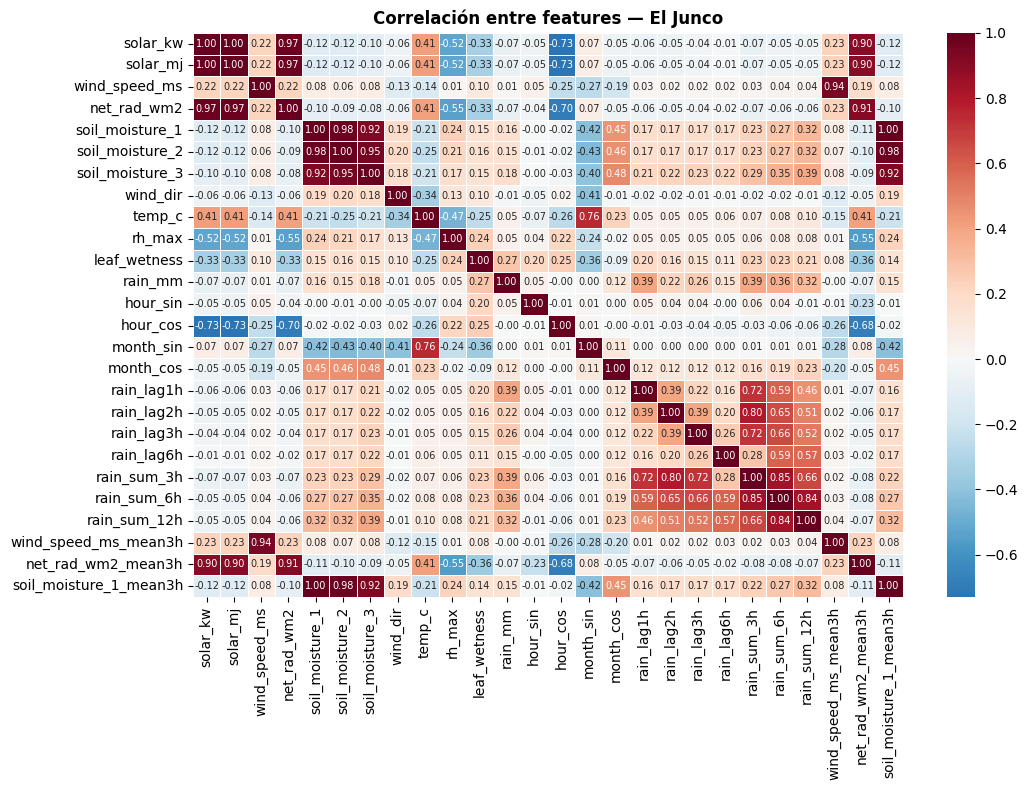

In [8]:
# Matriz de correlación con lluvia
plt.figure(figsize=(11, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlación entre features — El Junco', fontweight='bold')
plt.tight_layout()
plt.savefig('jun_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Etiquetas de Clasificación (3 Clases)

Metodología del EDA del hackathon (sección 4e):

| Clase | Nombre | Criterio (lluvia acumulada en horizonte) |
|---|---|---|
| 0 | No rain | = 0 mm |
| 1 | Light | 0 < lluvia ≤ umbral |
| 2 | Heavy | > umbral |

Umbrales: **+1h → 0.254 mm · +3h → 0.508 mm · +6h → 0.762 mm**

In [9]:
THRESHOLDS = {1: 0.254, 3: 0.508, 6: 0.762}

def make_labels(rain_series, horizon_h, threshold):
    """Suma acumulada en las próximas horizon_h horas → 3 clases."""
    future_acc = rain_series.rolling(horizon_h).sum().shift(-horizon_h)
    labels = np.where(future_acc == 0, 0,
             np.where(future_acc <= threshold, 1, 2))
    return pd.Series(labels.astype(np.int32),
                     index=rain_series.index,
                     name=f'label_{horizon_h}h')

for h, thr in THRESHOLDS.items():
    data[f'label_{h}h'] = make_labels(data[RAIN_COL], h, thr)

print('=== Balance de clases ===')
for h in THRESHOLDS:
    vc = data[f'label_{h}h'].value_counts().sort_index()
    total = vc.sum()
    print(f'\n+{h}h  (umbral = {THRESHOLDS[h]} mm):')
    for cls, name in enumerate(CLASS_NAMES):
        print(f'  {name:8s}: {vc.get(cls,0):6,}  ({vc.get(cls,0)/total*100:.1f}%)')

=== Balance de clases ===

+1h  (umbral = 0.254 mm):
  No rain : 19,250  (89.2%)
  Light   :  1,498  (6.9%)
  Heavy   :    826  (3.8%)

+3h  (umbral = 0.508 mm):
  No rain : 17,028  (78.9%)
  Light   :  2,780  (12.9%)
  Heavy   :  1,766  (8.2%)

+6h  (umbral = 0.762 mm):
  No rain : 14,970  (69.4%)
  Light   :  4,374  (20.3%)
  Heavy   :  2,230  (10.3%)


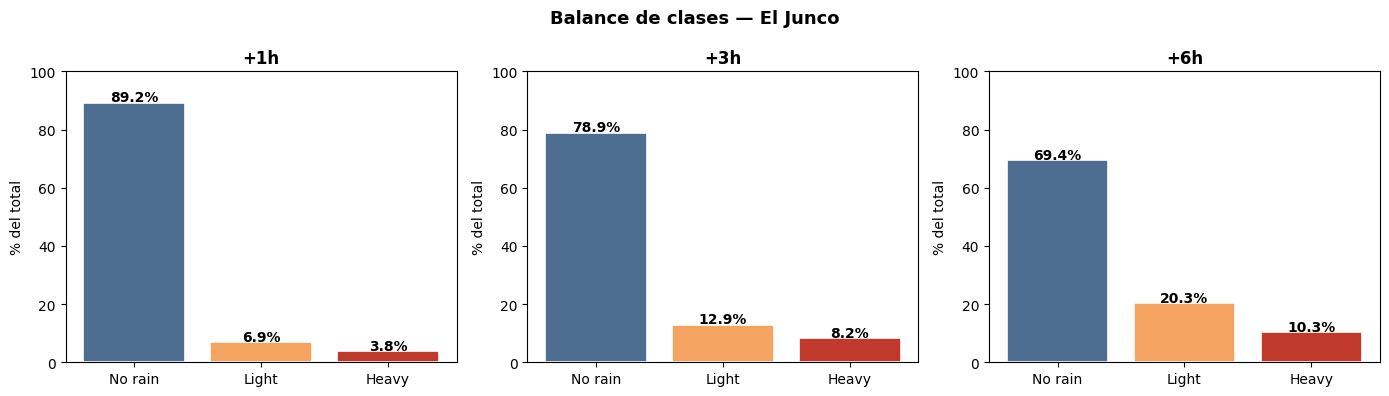

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h in zip(axes, THRESHOLDS):
    vc = data[f'label_{h}h'].value_counts().sort_index()
    total = vc.sum()
    bars = ax.bar(CLASS_NAMES,
                  [vc.get(i,0)/total*100 for i in range(3)],
                  color=RAIN_COLORS, edgecolor='white', linewidth=1.2)
    for bar, pct in zip(bars, [vc.get(i,0)/total*100 for i in range(3)]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'+{h}h', fontweight='bold')
    ax.set_ylabel('% del total')
    ax.set_ylim(0, 100)
plt.suptitle('Balance de clases — El Junco', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('jun_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. División Temporal y Normalización

In [15]:
# ── Parámetros globales ───────────────────────────────────────────────────────
LOOK_BACK  = 12   # 12 horas de historia
EPOCHS     = 100
BATCH_SIZE = 32
PATIENCE   = 15

# Columnas de features (sin etiquetas)
label_cols   = [f'label_{h}h' for h in THRESHOLDS]
feature_cols = [c for c in data.columns if c not in label_cols]
n_features   = len(feature_cols)

print(f'Features totales : {n_features}')
print(f'Lista            : {feature_cols}')

# ── Split temporal ajustado al rango real del dataset (2015-2020) ────────────
# Dataset: 2015-06-22 → 2020-11-27 (~5.4 años)
# Split: 70% Train / 15% Val / 15% Test
TRAIN_END = '2019-03-31 23:00'  # ~70% de los datos
VAL_END   = '2020-02-29 23:00'  # ~85% total (val = 15%)

train_df = data[data.index <= TRAIN_END]
val_df   = data[(data.index >  TRAIN_END) & (data.index <= VAL_END)]
test_df  = data[data.index  >  VAL_END]

print(f'\nTrain : {train_df.index.min()} → {train_df.index.max()}  ({len(train_df):,} filas)')
print(f'Val   : {val_df.index.min()} → {val_df.index.max()}  ({len(val_df):,} filas)')
print(f'Test  : {test_df.index.min()} → {test_df.index.max()}  ({len(test_df):,} filas)')


Features totales : 26
Lista            : ['solar_kw', 'solar_mj', 'wind_speed_ms', 'net_rad_wm2', 'soil_moisture_1', 'soil_moisture_2', 'soil_moisture_3', 'wind_dir', 'temp_c', 'rh_max', 'leaf_wetness', 'rain_mm', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'rain_lag1h', 'rain_lag2h', 'rain_lag3h', 'rain_lag6h', 'rain_sum_3h', 'rain_sum_6h', 'rain_sum_12h', 'wind_speed_ms_mean3h', 'net_rad_wm2_mean3h', 'soil_moisture_1_mean3h']

Train : 2015-06-22 21:00:00 → 2019-03-08 05:00:00  (14,103 filas)
Val   : 2019-12-20 00:00:00 → 2020-02-29 23:00:00  (1,708 filas)
Test  : 2020-03-01 00:00:00 → 2020-11-27 22:00:00  (5,763 filas)


In [16]:
# 🔍 DIAGNÓSTICO: Verifica que los splits no estén vacíos
print('=== DIAGNÓSTICO DE SPLITS ===')
print(f'\nRango completo del dataset:')
print(f'  Inicio: {data.index.min()}')
print(f'  Fin   : {data.index.max()}')
print(f'  Total : {len(data):,} filas')

print(f'\nTamaños de cada split:')
print(f'  Train: {len(train_df):,} filas')
print(f'  Val  : {len(val_df):,} filas')
print(f'  Test : {len(test_df):,} filas')

if len(val_df) == 0:
    print('\n❌ PROBLEMA: val_df está vacío!')
    print('   Revisa si el dataset tiene datos entre 2023-01-01 y 2024-06-30')
    print(f'\n   Solución: Ajustar TRAIN_END y VAL_END según el rango real de datos')


=== DIAGNÓSTICO DE SPLITS ===

Rango completo del dataset:
  Inicio: 2015-06-22 21:00:00
  Fin   : 2020-11-27 22:00:00
  Total : 21,574 filas

Tamaños de cada split:
  Train: 14,103 filas
  Val  : 1,708 filas
  Test : 5,763 filas


In [17]:
# Normalización MinMaxScaler — fit SOLO en train para evitar data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[feature_cols].values)

X_train_sc = scaler.transform(train_df[feature_cols].values).astype(np.float32)
X_val_sc   = scaler.transform(val_df[feature_cols].values).astype(np.float32)
X_test_sc  = scaler.transform(test_df[feature_cols].values).astype(np.float32)

print('Escalado ✅')
print(f'  Train : {X_train_sc.shape}')
print(f'  Val   : {X_val_sc.shape}')
print(f'  Test  : {X_test_sc.shape}')

Escalado ✅
  Train : (14103, 26)
  Val   : (1708, 26)
  Test  : (5763, 26)


## 7. Funciones Auxiliares

In [18]:
def create_sequences(X_scaled, labels_array, look_back):
    """
    Ventanas deslizantes para clasificación.
    Retorna:
      X : (N, look_back, n_features)
      y : (N,)  — etiqueta de clase en el paso t+1
    """
    X, y = [], []
    for i in range(len(X_scaled) - look_back):
        X.append(X_scaled[i : i + look_back])
        y.append(labels_array[i + look_back])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def build_gru(look_back, n_features, n_classes=3,
              units1=32, units2=16, dropout=0.3, lr=1e-3):
    """
    GRU de clasificación multiclase con salida softmax.
    """
    model = Sequential([
        GRU(units1, return_sequences=True,
            input_shape=(look_back, n_features),
            recurrent_dropout=0.1),
        Dropout(dropout),
        GRU(units2, return_sequences=False,
            recurrent_dropout=0.1),
        Dropout(dropout),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_class_weights(y):
    classes = np.unique(y)
    w = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes.astype(int), w))


def evaluate(y_true, y_pred, horizon_label):
    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro',   zero_division=0)
    f1_per   = f1_score(y_true, y_pred, average=None,      zero_division=0)
    f1_heavy = f1_per[2] if len(f1_per) > 2 else 0.0

    print(f'\n📊 Métricas — {horizon_label}')
    print(f'   Accuracy  : {acc:.4f}')
    print(f'   F1 macro  : {f1_macro:.4f}')
    print(f'   F1 Heavy  : {f1_heavy:.4f}  ← métrica principal')
    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES,
                                 zero_division=0))
    return {'horizon': horizon_label,
            'Accuracy': acc,
            'F1_macro': f1_macro,
            'F1_heavy': f1_heavy}


def plot_loss(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('Loss (cross-entropy)'); axes[0].legend()
    axes[1].plot(history.history['accuracy'],     label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend()
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


def plot_cm(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


CALLBACKS = lambda: [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print('✅ Funciones listas')

✅ Funciones listas


---
## 8. MODELO +1h

In [19]:
# Secuencias
X_tr1, y_tr1 = create_sequences(X_train_sc, train_df['label_1h'].values, LOOK_BACK)
X_vl1, y_vl1 = create_sequences(X_val_sc,   val_df['label_1h'].values,   LOOK_BACK)
X_ts1, y_ts1 = create_sequences(X_test_sc,  test_df['label_1h'].values,  LOOK_BACK)

cw_1h = get_class_weights(y_tr1)
print(f'Train {X_tr1.shape}  |  Val {X_vl1.shape}  |  Test {X_ts1.shape}')
print(f'Class weights: {cw_1h}')

Train (14091, 12, 26)  |  Val (1696, 12, 26)  |  Test (5751, 12, 26)
Class weights: {np.int64(0): np.float64(0.37854609929078015), np.int64(1): np.float64(4.6923076923076925), np.int64(2): np.float64(6.887096774193548)}


In [20]:
model_1h = build_gru(LOOK_BACK, n_features)
model_1h.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,211 (32.07 KB)

 Trainable params: 8,211 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_1h = model_1h.fit(
    X_tr1, y_tr1,
    validation_data=(X_vl1, y_vl1),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_1h, callbacks=CALLBACKS(), verbose=1
)

Epoch 1/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5579 - loss: 0.9785 - val_accuracy: 0.4994 - val_loss: 1.0341 - learning_rate: 0.0010
Epoch 2/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6311 - loss: 0.9163 - val_accuracy: 0.7188 - val_loss: 0.7939 - learning_rate: 0.0010
Epoch 3/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6542 - loss: 0.8950 - val_accuracy: 0.7642 - val_loss: 0.7730 - learning_rate: 0.0010
Epoch 4/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6570 - loss: 0.8867 - val_accuracy: 0.5236 - val_loss: 1.0370 - learning_rate: 0.0010
Epoch 5/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6643 - loss: 0.8765 - val_accuracy: 0.6680 - val_loss: 0.8475 - learning_rate: 0.0010
Epoch 6/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6661 - loss: 0.8683 - val_accuracy: 0.5660 - val_loss: 0.9843 - learning_rate: 0.0010
Epoch 7/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6768 - 

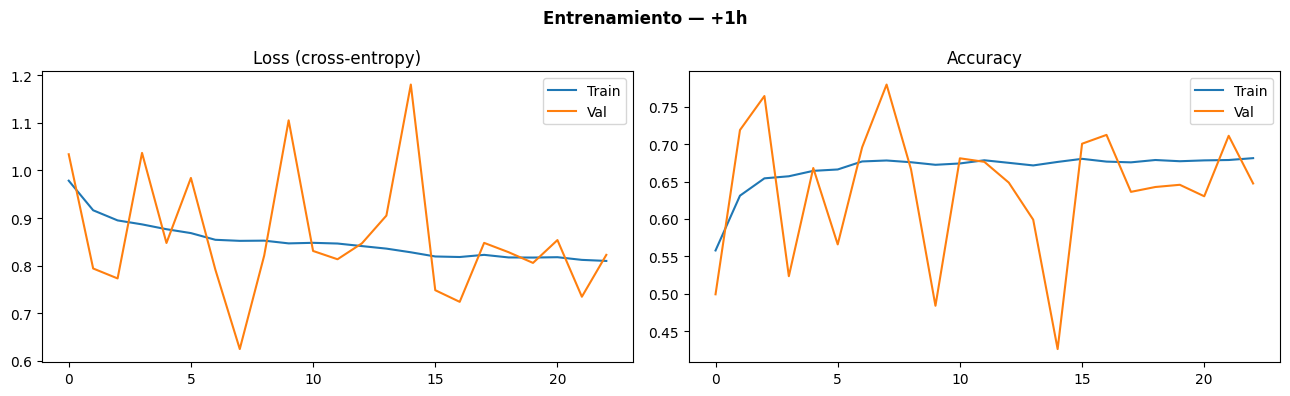

In [22]:
plot_loss(history_1h, 'Entrenamiento — +1h', 'jun_loss_1h.png')

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

📊 Métricas — +1h
   Accuracy  : 0.9061
   F1 macro  : 0.3726
   F1 Heavy  : 0.0784  ← métrica principal
              precision    recall  f1-score   support

     No rain       0.93      0.98      0.95      5295
       Light       0.20      0.06      0.09       388
       Heavy       0.12      0.06      0.08        68

    accuracy                           0.91      5751
   macro avg       0.41      0.36      0.37      5751
weighted avg       0.87      0.91      0.88      5751



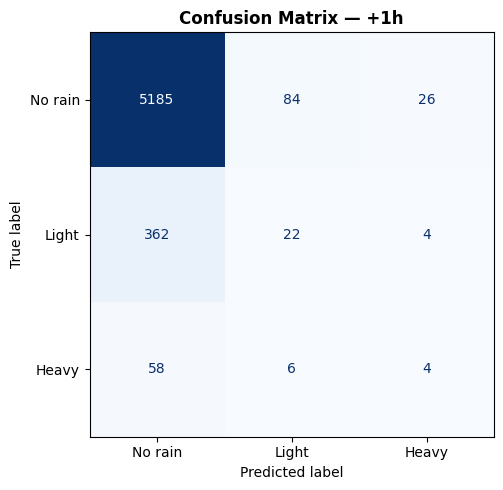

In [23]:
pred_1h    = model_1h.predict(X_ts1).argmax(axis=1)
metrics_1h = evaluate(y_ts1, pred_1h, '+1h')
plot_cm(y_ts1, pred_1h, 'Confusion Matrix — +1h', 'jun_cm_1h.png')

---
## 9. MODELO +3h

In [ ]:
X_tr3, y_tr3 = create_sequences(X_train_sc, train_df['label_3h'].values, LOOK_BACK)
X_vl3, y_vl3 = create_sequences(X_val_sc,   val_df['label_3h'].values,   LOOK_BACK)
X_ts3, y_ts3 = create_sequences(X_test_sc,  test_df['label_3h'].values,  LOOK_BACK)

cw_3h = get_class_weights(y_tr3)
print(f'Train {X_tr3.shape}  |  Val {X_vl3.shape}  |  Test {X_ts3.shape}')
print(f'Class weights: {cw_3h}')

In [ ]:
model_3h = build_gru(LOOK_BACK, n_features)

history_3h = model_3h.fit(
    X_tr3, y_tr3,
    validation_data=(X_vl3, y_vl3),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_3h, callbacks=CALLBACKS(), verbose=1
)

In [ ]:
plot_loss(history_3h, 'Entrenamiento — +3h', 'jun_loss_3h.png')

In [ ]:
pred_3h    = model_3h.predict(X_ts3).argmax(axis=1)
metrics_3h = evaluate(y_ts3, pred_3h, '+3h')
plot_cm(y_ts3, pred_3h, 'Confusion Matrix — +3h', 'jun_cm_3h.png')

---
## 10. MODELO +6h

In [ ]:
X_tr6, y_tr6 = create_sequences(X_train_sc, train_df['label_6h'].values, LOOK_BACK)
X_vl6, y_vl6 = create_sequences(X_val_sc,   val_df['label_6h'].values,   LOOK_BACK)
X_ts6, y_ts6 = create_sequences(X_test_sc,  test_df['label_6h'].values,  LOOK_BACK)

cw_6h = get_class_weights(y_tr6)
print(f'Train {X_tr6.shape}  |  Val {X_vl6.shape}  |  Test {X_ts6.shape}')
print(f'Class weights: {cw_6h}')

In [ ]:
# Horizonte más largo → arquitectura ligeramente mayor
model_6h = build_gru(LOOK_BACK, n_features,
                     units1=48, units2=24, dropout=0.3)

history_6h = model_6h.fit(
    X_tr6, y_tr6,
    validation_data=(X_vl6, y_vl6),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_6h, callbacks=CALLBACKS(), verbose=1
)

In [ ]:
plot_loss(history_6h, 'Entrenamiento — +6h', 'jun_loss_6h.png')

In [ ]:
pred_6h    = model_6h.predict(X_ts6).argmax(axis=1)
metrics_6h = evaluate(y_ts6, pred_6h, '+6h')
plot_cm(y_ts6, pred_6h, 'Confusion Matrix — +6h', 'jun_cm_6h.png')

---
## 11. Comparación Final

In [ ]:
results = pd.DataFrame([metrics_1h, metrics_3h, metrics_6h]).set_index('horizon')
print('\n=== RESUMEN COMPARATIVO ===')
print(results.to_string())
results

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric in zip(axes, ['Accuracy', 'F1_macro', 'F1_heavy']):
    bars = ax.bar(results.index, results[metric],
                  color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Comparación GRU — El Junco (+1h / +3h / +6h)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('jun_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Matrices de confusión juntas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (yt, yp, h) in zip(axes, [
    (y_ts1, pred_1h, '+1h'),
    (y_ts3, pred_3h, '+3h'),
    (y_ts6, pred_6h, '+6h')
]):
    ConfusionMatrixDisplay(
        confusion_matrix(yt, yp), display_labels=CLASS_NAMES
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Horizonte {h}', fontweight='bold')

plt.suptitle('Matrices de Confusión — El Junco', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('jun_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Guardado de Modelos

In [ ]:
model_1h.save('jun_gru_1h.keras')
model_3h.save('jun_gru_3h.keras')
model_6h.save('jun_gru_6h.keras')
joblib.dump(scaler,       'jun_scaler.pkl')
joblib.dump(feature_cols, 'jun_feature_cols.pkl')

print('✅ Guardados:')
for f in ['jun_gru_1h.keras','jun_gru_3h.keras','jun_gru_6h.keras',
          'jun_scaler.pkl','jun_feature_cols.pkl']:
    print(f'   {f}')

---
## 📝 Resumen Metodológico

| Etapa | Detalle |
|---|---|
| **Datos** | Dataset horario — 1 fila = 1 hora, sin resampleo |
| **Target** | Clasificación 3 clases: No rain (0) / Light (1) / Heavy (2) |
| **Umbrales** | +1h: 0.254 mm · +3h: 0.508 mm · +6h: 0.762 mm |
| **Features** | Variables meteorológicas base + temporales cíclicas + lags de lluvia + rolling sums |
| **Precursores EDA** | temp_c (+3.4°C), rh_max (+10%), soil_moisture_1 (+0.07 VWC), net_rad_wm2 (−47 W/m²) |
| **Ventana entrada** | 12 horas (look_back = 12) |
| **Arquitectura +1h/+3h** | GRU(32) → Drop(0.3) → GRU(16) → Drop(0.3) → Softmax(3) |
| **Arquitectura +6h** | GRU(48) → Drop(0.3) → GRU(24) → Drop(0.3) → Softmax(3) |
| **Desbalance** | class_weight='balanced' en todos los modelos |
| **Normalización** | MinMaxScaler [0,1] — fit solo en train |
| **Split** | Train ≤ 2019-03-31 · Val 2019-04 to 2020-02 · Test ≥ 2020-03-01 |
| **Callbacks** | EarlyStopping(patience=15) + ReduceLROnPlateau |
| **Métrica principal** | F1 Heavy (clase 2) + F1 macro |
